<a href="https://colab.research.google.com/github/sebastianvettel1212/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 1 — Exploratory Data Analysis (Analisis Data Eksploratif)

**Buku:** *Practical Statistics for Data Scientists* — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly)

Notebook ini berisi:
1. **Reproduksi kode** seluruh contoh pada Bab 1 (Python: `pandas`, `NumPy`, `SciPy`, `statsmodels`, `seaborn`, `Matplotlib`),
2. **Ringkasan** tiap subbab (*Key Ideas*), dan
3. **Penjelasan teori** dalam Bahasa Indonesia.

---

## Daftar Isi
0. [Persiapan: Library & Dataset](#0.-Persiapan:-Library-&-Dataset)
1. [Elemen Data Terstruktur](#1.-Elemen-Data-Terstruktur)
2. [Data Rectangular](#2.-Data-Rectangular)
3. [Estimasi Lokasi (*Estimates of Location*)](#3.-Estimasi-Lokasi-(Estimates-of-Location))
4. [Estimasi Variabilitas (*Estimates of Variability*)](#4.-Estimasi-Variabilitas-(Estimates-of-Variability))
5. [Mengeksplorasi Distribusi Data](#5.-Mengeksplorasi-Distribusi-Data)
6. [Mengeksplorasi Data Biner dan Kategorikal](#6.-Mengeksplorasi-Data-Biner-dan-Kategorikal)
7. [Korelasi](#7.-Korelasi)
8. [Mengeksplorasi Dua Variabel atau Lebih](#8.-Mengeksplorasi-Dua-Variabel-atau-Lebih)
9. [Ringkasan Bab](#9.-Ringkasan-Bab)

---

## Pengantar

Bab ini membahas **langkah pertama dalam setiap proyek data science: mengeksplorasi data**.

Statistika klasik hampir seluruhnya berfokus pada **inferensi**, yaitu prosedur untuk menarik kesimpulan tentang populasi besar berdasarkan sampel kecil. Pada tahun 1962, **John W. Tukey** lewat makalah *"The Future of Data Analysis"* mengusulkan disiplin ilmiah baru bernama **analisis data (data analysis)**, dengan inferensi statistik hanya sebagai salah satu komponennya. Tukey juga menjalin hubungan dengan komunitas *engineering* dan *computer science* (ia yang memopulerkan istilah *bit* dan *software*).

Bidang **EDA (Exploratory Data Analysis)** resmi lahir lewat buku Tukey tahun 1977. Ia memperkenalkan plot sederhana (mis. **boxplot** dan **scatterplot**) yang dipadukan dengan statistik ringkasan (rata-rata, median, kuantil, dst.) untuk menggambarkan isi suatu dataset. Kini, dengan komputasi yang murah dan perangkat lunak yang ekspresif, EDA berkembang jauh melampaui cakupan awalnya, tetapi gagasan intinya tetap sama:

> **Langkah pertama dan terpenting dalam proyek berbasis data adalah *melihat datanya*.**

## 0. Persiapan: Library & Dataset

Dataset yang dipakai berasal dari repositori resmi buku ([gedeck/practical-statistics-for-data-scientists](https://github.com/gedeck/practical-statistics-for-data-scientists)).

Fungsi `path_data()` di bawah akan:
- memakai file lokal di folder `data/` **jika ada**, atau
- **mengunduh otomatis** dari GitHub jika file lokal tidak ditemukan.

Jadi notebook ini dapat langsung dijalankan (termasuk di Google Colab) tanpa menyiapkan data secara manual.

Library yang dibutuhkan: `pandas numpy scipy statsmodels seaborn matplotlib wquantiles scikit-learn`

In [6]:
# Jalankan sel ini (hapus tanda #) bila library belum terpasang
# !pip install pandas numpy scipy statsmodels seaborn matplotlib wquantiles scikit-learn

In [7]:
!pip install pandas numpy scipy statsmodels seaborn matplotlib wquantiles scikit-learn

In [8]:
import warnings
from itertools import permutations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wquantiles
from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize
from scipy.stats import trim_mean
from statsmodels import robust

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.float_format = '{:,.4f}'.format

In [9]:
# Lokasi dataset: folder lokal 'data/' atau, bila tidak ada, langsung dari GitHub
DATA_DIR = Path('data')
RAW_URL = ('https://raw.githubusercontent.com/gedeck/'
           'practical-statistics-for-data-scientists/master/data/')

def path_data(nama_file):
    lokal = DATA_DIR / nama_file
    return lokal if lokal.exists() else RAW_URL + nama_file

STATE_CSV        = path_data('state.csv')            # populasi & tingkat pembunuhan per negara bagian AS
DFW_AIRLINE_CSV  = path_data('dfw_airline.csv')      # penyebab keterlambatan penerbangan di bandara DFW
AIRLINE_STATS_CSV = path_data('airline_stats.csv')   # persentase keterlambatan per maskapai
SP500_DATA_CSV   = path_data('sp500_data.csv.gz')    # return harian saham S&P 500
SP500_SECTORS_CSV = path_data('sp500_sectors.csv')   # sektor tiap simbol saham
KC_TAX_CSV       = path_data('kc_tax.csv.gz')        # nilai taksiran pajak properti di King County
LC_LOANS_CSV     = path_data('lc_loans.csv')         # data pinjaman Lending Club

---
## 1. Elemen Data Terstruktur

Data berasal dari banyak sumber: pengukuran sensor, *event*, teks, gambar, dan video. *Internet of Things* (IoT) terus menghasilkan aliran informasi. Sebagian besar data ini **tidak terstruktur**:
- **Gambar** = kumpulan piksel, tiap piksel berisi informasi warna RGB.
- **Teks** = urutan kata dan karakter bukan-kata, biasanya diorganisasi per bagian/subbagian.
- **Clickstream** = urutan aksi pengguna pada aplikasi atau halaman web.

Tantangan utama data science adalah mengubah banjir data mentah ini menjadi **informasi yang dapat ditindaklanjuti**. Agar konsep statistik dapat diterapkan, data mentah harus diolah menjadi **bentuk terstruktur**; bentuk yang paling umum adalah **tabel dengan baris dan kolom** (seperti dari basis data relasional atau hasil pengumpulan data penelitian).

### Dua tipe dasar data terstruktur

| Tipe | Subtipe | Penjelasan | Sinonim | Contoh |
|---|---|---|---|---|
| **Numerik** | **Kontinu** (*continuous*) | Dapat bernilai apa saja dalam suatu interval | interval, float, numeric | kecepatan angin, durasi waktu |
| | **Diskrit** (*discrete*) | Hanya bernilai bilangan bulat, biasanya hasil penghitungan | integer, count | jumlah kemunculan suatu event |
| **Kategorikal** | **Biner** (*binary*) | Kasus khusus kategorikal dengan hanya 2 nilai | dichotomous, logical, indicator, boolean | 0/1, ya/tidak, true/false |
| | **Ordinal** (*ordinal*) | Kategorikal yang memiliki **urutan** | ordered factor | rating 1, 2, 3, 4, 5 |
| | Nominal (umum) | Himpunan nilai tetap tanpa urutan | enums, enumerated, factors, nominal | jenis layar TV (plasma, LCD, LED), nama negara bagian |

### Mengapa perlu taksonomi tipe data?
Untuk analisis data dan pemodelan prediktif, **tipe data menentukan jenis visualisasi, analisis, dan model statistik** yang cocok. Perangkat lunak (R, Python) juga memakai tipe data untuk meningkatkan performa komputasi dan menentukan **cara penghitungan** suatu variabel.

Bagi *software engineer* atau pemrogram basis data, kategori hanyalah kumpulan teks/angka. Namun, mengidentifikasi data sebagai **kategorikal** (berbeda dari teks biasa) memberikan beberapa keuntungan:
1. Menjadi **sinyal** bagi perangkat lunak tentang bagaimana prosedur statistik (membuat grafik, mencocokkan model) harus berperilaku. Data ordinal, misalnya, dapat disimpan sebagai `ordered.factor` di R (atau `OrdinalEncoder` di scikit-learn) agar urutannya terjaga di grafik, tabel, dan model.
2. **Penyimpanan dan pengindeksan** dapat dioptimalkan.
3. Nilai yang mungkin muncul **dibatasi** oleh perangkat lunak (seperti `enum`).

Keuntungan ketiga bisa menimbulkan perilaku tak terduga: fungsi `read.csv` di R secara default mengubah kolom teks menjadi *factor*, sehingga menugaskan nilai teks baru akan menghasilkan peringatan dan `NA`. Di Python, `pandas` **tidak** melakukan konversi otomatis, tetapi kita bisa menetapkan kolom sebagai kategorikal secara eksplisit lewat `read_csv`.

### Key Ideas
- Data umumnya diklasifikasikan di perangkat lunak berdasarkan **tipe**.
- Tipe data mencakup **numerik** (kontinu, diskrit) dan **kategorikal** (biner, ordinal).
- Penetapan tipe data berfungsi sebagai **sinyal** bagi perangkat lunak tentang cara memproses data.

In [10]:
# Contoh berbagai tipe data pada pandas
df_tipe = pd.DataFrame({
    'kecepatan_angin': [3.2, 5.1, 4.8, 6.0],                 # numerik kontinu
    'jumlah_klik':     [10, 3, 7, 0],                        # numerik diskrit
    'jenis_layar':     ['LED', 'LCD', 'Plasma', 'LED'],      # kategorikal (nominal)
    'lulus':           [True, False, True, True],            # biner
    'rating':          [4, 2, 5, 3],                         # ordinal
})

# Menetapkan tipe kategorikal secara eksplisit
df_tipe['jenis_layar'] = df_tipe['jenis_layar'].astype('category')
df_tipe['rating'] = pd.Categorical(df_tipe['rating'],
                                   categories=[1, 2, 3, 4, 5], ordered=True)

print(df_tipe.dtypes)
print()
print('Kategori jenis_layar :', list(df_tipe['jenis_layar'].cat.categories))
print('Rating terurut?      :', df_tipe['rating'].cat.ordered)
print('Rating >= 3          :', list(df_tipe['rating'] >= 3))

kecepatan_angin     float64
jumlah_klik           int64
jenis_layar        category
lulus                  bool
rating             category
dtype: object

Kategori jenis_layar : ['LCD', 'LED', 'Plasma']
Rating terurut?      : True
Rating >= 3          : [True, False, True, True]


In [11]:
# Data ordinal pada scikit-learn: OrdinalEncoder mempertahankan urutan kategori yang kita tentukan
from sklearn.preprocessing import OrdinalEncoder

ukuran = pd.DataFrame({'ukuran': ['S', 'L', 'M', 'XL', 'M']})
encoder = OrdinalEncoder(categories=[['S', 'M', 'L', 'XL']])
ukuran['ukuran_ordinal'] = encoder.fit_transform(ukuran[['ukuran']]).astype(int)
ukuran

,ukuran,ukuran_ordinal
0,S,0
1,L,2
2,M,1
3,XL,3
4,M,1


In [12]:
# pandas tidak otomatis mengubah teks menjadi kategori, tetapi bisa ditetapkan eksplisit di read_csv
state_tmp = pd.read_csv(STATE_CSV, dtype={'Abbreviation': 'category'})
print(state_tmp.dtypes)

State             object
Population         int64
Murder.Rate      float64
Abbreviation    category
dtype: object


---
## 2. Data Rectangular

Kerangka acuan umum untuk analisis di data science adalah **objek data rectangular**, seperti *spreadsheet* atau tabel basis data.

**Data rectangular** adalah istilah umum untuk matriks dua dimensi dengan **baris = record (kasus)** dan **kolom = fitur (variabel)**. *Data frame* adalah format spesifiknya di R dan Python. Data tidak selalu berawal dalam bentuk ini: data tak terstruktur (mis. teks) harus diolah agar dapat direpresentasikan sebagai sekumpulan fitur, dan data dari basis data relasional biasanya harus digabung menjadi satu tabel.

### Istilah Kunci

| Istilah | Penjelasan | Sinonim |
|---|---|---|
| **Data frame** | Data rectangular (seperti spreadsheet); struktur data dasar untuk model statistik & *machine learning* | — |
| **Feature** (fitur) | Sebuah **kolom** dalam tabel | attribute, input, predictor, variable |
| **Outcome** (hasil) | Variabel yang ingin **diprediksi**; fitur dipakai untuk memprediksinya | dependent variable, response, target, output |
| **Record** | Sebuah **baris** dalam tabel | case, example, instance, observation, pattern, sample |

Pada Tabel 1-1 (data lelang), terdapat campuran data terukur/terhitung (durasi, harga) dan data kategorikal (kategori, mata uang). Kolom paling kanan, `Competitive?`, adalah **variabel biner (indikator)** yang juga menjadi **variabel outcome** bila skenarionya adalah memprediksi apakah suatu lelang kompetitif (memiliki beberapa penawar) atau tidak.

### Data Frame dan Index
- Tabel basis data tradisional punya satu atau lebih kolom sebagai **index** (pada dasarnya nomor baris) yang meningkatkan efisiensi *query* tertentu.
- Di Python, struktur dasarnya adalah `DataFrame` dari `pandas`. Secara default dibuat **index bilangan bulat otomatis** berdasarkan urutan baris, dan juga dimungkinkan membuat **index bertingkat (multilevel/hierarchical)**.
- Di R, struktur dasarnya `data.frame` (dengan index implisit); paket `data.table` dan `dplyr` menambah dukungan index bertingkat dan kecepatan.

> **Perbedaan terminologi.** Bagi statistisi, *predictor* dipakai dalam model untuk memprediksi *response*. Bagi data scientist, *feature* dipakai untuk memprediksi *target*. Satu sinonim yang membingungkan: ilmuwan komputer memakai **sample** untuk **satu baris**, sedangkan bagi statistisi **sample** adalah **kumpulan baris**.

### Struktur Data Non-Rectangular
- **Data deret waktu (*time series*)**: pengukuran berurutan atas variabel yang sama; bahan baku peramalan statistik dan komponen kunci data dari perangkat IoT.
- **Struktur data spasial**: dipakai dalam pemetaan dan analitik lokasi. *Representasi objek* berfokus pada objek (mis. rumah) dan koordinatnya; *field view* berfokus pada satuan ruang kecil dan nilai metriknya (mis. kecerahan piksel).
- **Struktur graf (jaringan)**: merepresentasikan hubungan fisik, sosial, dan abstrak (mis. jaringan sosial, jaringan jalan distribusi). Berguna untuk optimisasi jaringan dan *recommender system*.

Fokus buku ini adalah **data rectangular**, fondasi pemodelan prediktif.

> **Graf dalam statistika.** Di ilmu komputer, *graph* berarti gambaran koneksi antar entitas (dan struktur datanya). Di statistika, *graph* merujuk pada berbagai plot/visualisasi, hanya visualisasinya, bukan struktur datanya.

### Key Ideas
- Struktur data dasar dalam data science adalah **matriks rectangular**: baris = *record*, kolom = variabel (*feature*).
- Terminologinya membingungkan karena banyak sinonim dari disiplin yang berbeda (statistika, ilmu komputer, teknologi informasi).

In [13]:
# Mereproduksi Tabel 1-1: contoh format data frame (data lelang)
tabel_1_1 = pd.DataFrame({
    'Category':     ['Music/Movie/Game', 'Music/Movie/Game', 'Automotive', 'Automotive',
                     'Automotive', 'Automotive', 'Automotive', 'Automotive'],
    'currency':     ['US'] * 8,
    'sellerRating': [3249, 3249, 3115, 3115, 3115, 3115, 3115, 3115],
    'Duration':     [5, 5, 7, 7, 7, 7, 7, 7],
    'endDay':       ['Mon', 'Mon', 'Tue', 'Tue', 'Tue', 'Tue', 'Tue', 'Tue'],
    'ClosePrice':   [0.01] * 8,
    'OpenPrice':    [0.01] * 8,
    'Competitive?': [0, 0, 0, 0, 0, 0, 1, 1],
})
tabel_1_1

,Category,currency,sellerRating,Duration,endDay,ClosePrice,OpenPrice,Competitive?
0,Music/Movie/Game,US,3249,5,Mon,0.0100,0.0100,0
1,Music/Movie/Game,US,3249,5,Mon,0.0100,0.0100,0
2,Automotive,US,3115,7,Tue,0.0100,0.0100,0
3,Automotive,US,3115,7,Tue,0.0100,0.0100,0
4,Automotive,US,3115,7,Tue,0.0100,0.0100,0
5,Automotive,US,3115,7,Tue,0.0100,0.0100,0
6,Automotive,US,3115,7,Tue,0.0100,0.0100,1
7,Automotive,US,3115,7,Tue,0.0100,0.0100,1


In [14]:
# Tiap kolom = fitur, tiap baris = record. Perhatikan tipe data tiap kolom dan index otomatis.
print('Jumlah record (baris), fitur (kolom):', tabel_1_1.shape)
print('Index default :', tabel_1_1.index)
print()
print(tabel_1_1.dtypes)

Jumlah record (baris), fitur (kolom): (8, 8)
Index default : RangeIndex(start=0, stop=8, step=1)

Category         object
currency         object
sellerRating      int64
Duration          int64
endDay           object
ClosePrice      float64
OpenPrice       float64
Competitive?      int64
dtype: object


In [15]:
# Index bertingkat (multilevel/hierarchical index) pada pandas
tabel_1_1.set_index(['Category', 'endDay'])

currency  sellerRating  Duration  ClosePrice  \
Category         endDay                                                
Music/Movie/Game Mon          US          3249         5      0.0100   
                 Mon          US          3249         5      0.0100   
Automotive       Tue          US          3115         7      0.0100   
                 Tue          US          3115         7      0.0100   
                 Tue          US          3115         7      0.0100   
                 Tue          US          3115         7      0.0100   
                 Tue          US          3115         7      0.0100   
                 Tue          US          3115         7      0.0100   

                         OpenPrice  Competitive?  
Category         endDay                           
Music/Movie/Game Mon        0.0100             0  
                 Mon        0.0100             0  
Automotive       Tue        0.0100             0  
                 Tue        0.0100             0  
                 Tue        0.0100             0  
                 Tue        0.0100             0  
                 Tue        0.0100             1  
                 Tue        0.0100             1

---
## 3. Estimasi Lokasi (*Estimates of Location*)

Variabel dengan data terukur atau hasil hitung bisa memiliki ribuan nilai berbeda. Langkah dasar eksplorasi adalah mencari **"nilai tipikal"** untuk tiap fitur: estimasi di mana sebagian besar data berada, atau disebut **kecenderungan memusat (*central tendency*)**.

### Istilah Kunci

| Istilah | Penjelasan | Sinonim |
|---|---|---|
| **Mean** | Jumlah seluruh nilai dibagi banyaknya nilai | average |
| **Weighted mean** | Jumlah (nilai × bobot) dibagi jumlah bobot | weighted average |
| **Median** | Nilai yang membagi data: separuh di atas dan separuh di bawahnya | 50th percentile |
| **Percentile** | Nilai sehingga P persen data berada di bawahnya | quantile |
| **Weighted median** | Nilai sehingga separuh jumlah bobot berada di atas dan separuh di bawah data terurut | — |
| **Trimmed mean** | Rata-rata setelah membuang sejumlah tetap nilai ekstrem | truncated mean |
| **Robust** | Tidak sensitif terhadap nilai ekstrem | resistant |
| **Outlier** | Nilai data yang sangat berbeda dari sebagian besar data | extreme value |

> **Metrik vs Estimasi.** Statistisi memakai istilah *estimasi* untuk nilai yang dihitung dari data di tangan, guna membedakannya dari keadaan teoretis yang sebenarnya. Data scientist dan analis bisnis lebih sering menyebutnya *metrik*. Perbedaannya mencerminkan pendekatan: statistika berfokus pada **ketidakpastian**, data science berfokus pada **tujuan bisnis** yang konkret. *Statistisi mengestimasi, data scientist mengukur.*

### Mean (rata-rata)
Estimasi lokasi paling dasar. Untuk himpunan $n$ nilai $x_1, x_2, \dots, x_n$:

$$\text{Mean} = \bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

Contoh: $\{3, 5, 1, 2\}$ → $(3+5+1+2)/4 = 2{,}75$. (Huruf kapital $N$ dipakai untuk populasi, huruf kecil $n$ untuk sampel.)

### Trimmed Mean
Dihitung dengan membuang $p$ nilai terkecil dan $p$ nilai terbesar dari data terurut $x_{(1)} \le \dots \le x_{(n)}$, lalu merata-ratakan sisanya:

$$\text{Trimmed mean} = \bar{x}_{p} = \frac{\sum_{i=p+1}^{n-p} x_{(i)}}{n - 2p}$$

Trimmed mean menghilangkan pengaruh nilai ekstrem. Contoh: pada penilaian loncat indah internasional, skor tertinggi dan terendah dari lima juri dibuang, sehingga satu juri sulit memanipulasi skor demi negaranya.

### Weighted Mean
Tiap nilai $x_i$ dikalikan bobot $w_i$ yang ditentukan pengguna, lalu dibagi jumlah bobot:

$$\text{Weighted mean} = \bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}$$

Dua motivasi utama menggunakan weighted mean:
1. Sebagian nilai secara intrinsik **lebih bervariasi** daripada yang lain, sehingga observasi yang sangat bervariasi diberi bobot lebih rendah (mis. sensor yang kurang akurat diberi bobot lebih kecil).
2. Data yang terkumpul **tidak mewakili semua kelompok secara merata** (mis. karena cara eksperimen online dilakukan), sehingga kelompok yang kurang terwakili diberi bobot lebih tinggi.

### Median dan Estimasi Robust
**Median** adalah nilai tengah pada daftar data terurut. Bila banyak data genap, median adalah rata-rata dua nilai tengah. Berbeda dengan mean yang memakai semua observasi, median hanya bergantung pada nilai di tengah data terurut. Ini justru keunggulan pada banyak kasus: pada contoh pendapatan rumah tangga di sekitar Danau Washington (Seattle), membandingkan lingkungan Medina dan Windermere memakai mean akan sangat menyesatkan karena **Bill Gates tinggal di Medina**. Dengan median, sekaya apa pun Bill Gates, posisi observasi tengah tidak berubah.

**Weighted median** dihitung dengan mengurutkan data (tiap nilai punya bobot), lalu mencari nilai sehingga jumlah bobot di bagian bawah dan atas daftar sama. Seperti median, weighted median robust terhadap outlier.

### Outlier
Median disebut estimasi **robust** karena tidak dipengaruhi **outlier** (kasus ekstrem). Definisi persisnya agak subjektif. Perlu dicatat:
- Menjadi outlier **tidak otomatis berarti data tidak valid** (seperti kasus Bill Gates).
- Namun, outlier sering akibat **kesalahan data**: campur aduk satuan (kilometer vs meter) atau pembacaan sensor yang buruk. Pada kasus ini mean menjadi estimasi buruk, sedangkan median tetap valid.
- Outlier sebaiknya selalu **diidentifikasi** dan biasanya layak diselidiki lebih lanjut.

> **Anomaly detection.** Berbeda dengan analisis data biasa (outlier kadang informatif, kadang gangguan), pada *anomaly detection* **outlier-lah yang menjadi titik perhatian**, sedangkan sebagian besar data hanya mendefinisikan "normal" sebagai pembanding.

Median bukan satu-satunya estimasi robust. **Trimmed mean** juga luas dipakai (memangkas 10% terbawah dan teratas adalah pilihan umum); ia dapat dilihat sebagai **kompromi antara median dan mean**: robust terhadap nilai ekstrem, tetapi memakai lebih banyak data.

### Contoh: Estimasi Lokasi untuk Populasi dan *Murder Rate*
Dataset `state` berisi populasi dan tingkat pembunuhan (pembunuhan per 100.000 orang per tahun) tiap negara bagian AS (Sensus 2010).

In [16]:
# Tabel 1-2: beberapa baris pertama data state
state = pd.read_csv(STATE_CSV)
state.head(8)

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7000,AL
1,Alaska,710231,5.6000,AK
2,Arizona,6392017,4.7000,AZ
3,Arkansas,2915918,5.6000,AR
4,California,37253956,4.4000,CA
5,Colorado,5029196,2.8000,CO
6,Connecticut,3574097,2.4000,CT
7,Delaware,897934,5.8000,DE


In [17]:
# Mean, trimmed mean (membuang 10% di tiap ujung), dan median dari populasi
mean_pop = state['Population'].mean()
trimmed_pop = trim_mean(state['Population'], 0.1)
median_pop = state['Population'].median()

print(f'Mean         : {mean_pop:>14,.0f}')
print(f'Trimmed mean : {trimmed_pop:>14,.0f}')
print(f'Median       : {median_pop:>14,.0f}')

Mean         :      6,162,876
Trimmed mean :      4,783,697
Median       :      4,436,370


**Interpretasi:** mean > trimmed mean > median. Mean paling besar karena ditarik oleh negara bagian berpopulasi sangat besar (mis. California). Trimmed mean (`0,1`) membuang **5 negara bagian terkecil dan 5 terbesar** (10% dari 50 di tiap ujung), sehingga lebih kecil dari mean. Median tidak terpengaruh nilai ekstrem sama sekali.

In [18]:
# Verifikasi: implementasi manual trimmed mean = hasil scipy.stats.trim_mean
def trimmed_mean_manual(x, proporsi):
    x_urut = np.sort(np.asarray(x))
    n = len(x_urut)
    p = int(n * proporsi)             # banyak nilai yang dibuang di SETIAP ujung
    return x_urut[p:n - p].mean()     # rata-rata (n - 2p) nilai di tengah

print('n =', len(state), '| p =', int(len(state) * 0.1))
print('Manual :', trimmed_mean_manual(state['Population'], 0.1))
print('SciPy  :', trim_mean(state['Population'], 0.1))

n = 50 | p = 5
Manual : 4783697.125
SciPy  : 4783697.125


In [19]:
# Demonstrasi sensitivitas mean vs median terhadap outlier (analogi kasus 'Bill Gates')
pendapatan = pd.Series([52, 48, 61, 55, 47, 58, 50, 63, 54, 49])   # contoh pendapatan (juta/tahun)
dengan_outlier = pd.concat([pendapatan, pd.Series([100_000])], ignore_index=True)  # satu orang super kaya

ringkas = pd.DataFrame({
    'Tanpa outlier':   [pendapatan.mean(), pendapatan.median(), trim_mean(pendapatan, 0.1)],
    'Dengan outlier':  [dengan_outlier.mean(), dengan_outlier.median(), trim_mean(dengan_outlier, 0.1)],
}, index=['Mean', 'Median', 'Trimmed mean (10%)'])
ringkas

,Tanpa outlier,Dengan outlier
Mean,53.7000,"9,139.7273"
Median,53.0000,54.0000
Trimmed mean (10%),53.3750,54.4444


**Interpretasi:** satu outlier ekstrem membuat **mean melonjak drastis**, sedangkan **median nyaris tidak berubah**. Inilah alasan median disebut *robust*.

Selanjutnya, untuk menghitung rata-rata *murder rate* nasional kita **tidak boleh** memakai mean biasa, sebab tiap negara bagian memiliki populasi berbeda. Kita memerlukan **weighted mean** atau **weighted median** dengan bobot = populasi.

In [20]:
# Weighted mean (NumPy) dan weighted median (paket wquantiles), bobot = populasi
murder_mean_biasa = state['Murder.Rate'].mean()
murder_weighted_mean = np.average(state['Murder.Rate'], weights=state['Population'])
murder_weighted_median = wquantiles.median(state['Murder.Rate'], weights=state['Population'])

print(f'Mean biasa (tanpa bobot) : {murder_mean_biasa:.4f}')
print(f'Weighted mean            : {murder_weighted_mean:.4f}')
print(f'Weighted median          : {murder_weighted_median:.4f}')

Mean biasa (tanpa bobot) : 4.0660
Weighted mean            : 4.4458
Weighted median          : 4.4000


**Interpretasi:** weighted mean (≈ 4,45) dan weighted median (≈ 4,4) hampir sama, dan keduanya berbeda dari mean biasa (≈ 4,07) karena negara bagian berpopulasi besar kini memiliki pengaruh lebih besar.

### Key Ideas
- Metrik dasar untuk lokasi adalah **mean**, tetapi **sensitif terhadap nilai ekstrem (outlier)**.
- Metrik lain (**median**, **trimmed mean**) kurang sensitif terhadap outlier dan distribusi tak lazim, sehingga lebih **robust**.

---
## 4. Estimasi Variabilitas (*Estimates of Variability*)

Lokasi hanyalah satu dimensi untuk meringkas sebuah fitur. Dimensi kedua adalah **variabilitas** (disebut juga **dispersi**), yang mengukur apakah nilai data **mengelompok rapat atau menyebar**. Statistika pada intinya adalah tentang variabilitas: mengukurnya, menguranginya, membedakan variabilitas acak dari yang nyata, mengidentifikasi sumber-sumber variabilitas nyata, dan mengambil keputusan di tengah variabilitas.

### Istilah Kunci

| Istilah | Penjelasan | Sinonim |
|---|---|---|
| **Deviations** | Selisih antara nilai observasi dan estimasi lokasi | errors, residuals |
| **Variance** | Jumlah kuadrat deviasi dari mean dibagi $n-1$ | mean-squared-error |
| **Standard deviation** | Akar kuadrat dari variansi | — |
| **Mean absolute deviation** | Rata-rata nilai mutlak deviasi dari mean | l1-norm, Manhattan norm |
| **Median absolute deviation from the median (MAD)** | Median dari nilai mutlak deviasi dari median | — |
| **Range** | Selisih nilai terbesar dan terkecil | — |
| **Order statistics** | Metrik berdasarkan data yang diurutkan dari kecil ke besar | ranks |
| **Percentile** | Nilai sehingga P persen data ≤ nilai itu dan (100−P) persen ≥ nilai itu | quantile |
| **Interquartile range (IQR)** | Selisih persentil ke-75 dan persentil ke-25 | IQR |

### Standar Deviasi dan Estimasi Terkait
Estimasi variasi yang paling banyak dipakai didasarkan pada **deviasi**: selisih antara estimasi lokasi dan data observasi. Untuk data $\{1, 4, 4\}$: mean = 3, median = 4, deviasi dari mean = $\{-2, 1, 1\}$.

Merata-ratakan deviasi mentah tidak berguna karena yang negatif meniadakan yang positif; faktanya **jumlah deviasi dari mean selalu tepat nol**. Pendekatan sederhana: rata-rata nilai mutlak deviasi, disebut **mean absolute deviation**:

$$\text{Mean absolute deviation} = \frac{\sum_{i=1}^{n} |x_i - \bar{x}|}{n}$$

Estimasi variabilitas yang paling terkenal adalah **variansi** dan **standar deviasi** yang berbasis kuadrat deviasi:

$$\text{Variance} = s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1} \qquad\qquad \text{Standard deviation} = s = \sqrt{\text{Variance}}$$

Standar deviasi lebih mudah ditafsirkan daripada variansi karena **berada pada skala yang sama dengan data asli**. Meski rumusnya lebih rumit, standar deviasi lebih disukai dalam statistika daripada mean absolute deviation karena **teori statistik**: secara matematis, bekerja dengan nilai kuadrat jauh lebih nyaman daripada nilai mutlak, terutama untuk model statistik.

> **Derajat kebebasan: $n$ atau $n-1$?** Bila memakai penyebut $n$, variansi dan standar deviasi populasi akan **diremehkan (*underestimate*)**; ini disebut *biased estimate*. Dengan penyebut $n-1$, variansi menjadi **estimasi tak bias (*unbiased*)**. Alasannya terkait **derajat kebebasan (*degrees of freedom*)**: ada $n-1$ derajat kebebasan karena ada satu kendala, yaitu perhitungan bergantung pada mean sampel. Untuk $n$ besar, perbedaan keduanya tidak berarti; data scientist umumnya tidak perlu mempermasalahkannya.

### Robust: Median Absolute Deviation (MAD)
Variansi, standar deviasi, maupun mean absolute deviation **tidak robust** terhadap outlier. Variansi dan standar deviasi **paling sensitif** karena berbasis kuadrat deviasi. Estimasi variabilitas yang robust adalah **MAD**:

$$\text{MAD} = \text{Median}\big(|x_1 - m|,\ |x_2 - m|,\ \dots,\ |x_N - m|\big), \quad m = \text{median}$$

> **Catatan.** Variansi, standar deviasi, mean absolute deviation, dan MAD **tidak ekuivalen**, bahkan untuk data dari distribusi normal. Standar deviasi selalu lebih besar dari mean absolute deviation, yang sendirinya lebih besar dari MAD. MAD kadang dikalikan konstanta **1,4826** agar sejajar dengan skala standar deviasi untuk distribusi normal (yang berarti 50% distribusi normal berada dalam rentang ±MAD).

### Estimasi Berbasis Persentil
Pendekatan lain adalah memeriksa **sebaran data terurut** (*order statistics*). Ukuran paling dasar adalah **range** (maks − min). Nilai min dan maks berguna untuk mengenali outlier, tetapi range **sangat sensitif terhadap outlier**.

Persentil ke-$P$ adalah nilai sehingga setidaknya $P$ persen data bernilai ≤ nilai itu. Untuk mencari persentil ke-80: urutkan data, lalu maju 80% dari nilai terkecil menuju terbesar. **Median = persentil ke-50.** Persentil sama dengan **kuantil** (kuantil 0,8 = persentil ke-80).

Ukuran variabilitas umum: selisih persentil ke-25 dan ke-75, yaitu **interquartile range (IQR)**. Contoh: $\{3,1,5,3,6,7,2,9\}$ → terurut $\{1,2,3,3,5,6,7,9\}$; persentil ke-25 = 2,5 dan ke-75 = 6,5, sehingga IQR = 4. Perangkat lunak dapat memakai pendekatan sedikit berbeda sehingga hasilnya bisa berbeda tipis (lihat kode di bawah).

> **Definisi persentil yang presisi.** Bila $n$ genap, persentil ambigu: nilainya bisa berada di antara statistik terurut $x_{(j)}$ dan $x_{(j+1)}$. Secara formal persentil adalah rata-rata berbobot $(1-w)\,x_{(j)} + w\,x_{(j+1)}$ untuk $0 \le w \le 1$. Perangkat lunak berbeda memilih $w$ secara berbeda (R punya 9 alternatif; `numpy.quantile` secara default memakai interpolasi linear). Kecuali untuk dataset kecil, ini umumnya tidak perlu dikhawatirkan.

In [21]:
# Contoh data {1, 4, 4}: deviasi dan mean absolute deviation
x = np.array([1, 4, 4])
deviasi = x - x.mean()

print('Mean                    :', x.mean())
print('Median                  :', np.median(x))
print('Deviasi dari mean       :', deviasi)
print('Jumlah deviasi          :', deviasi.sum(), '  <- selalu nol')
print('Mean absolute deviation :', round(np.abs(deviasi).mean(), 4))

Mean                    : 3.0
Median                  : 4.0
Deviasi dari mean       : [-2.  1.  1.]
Jumlah deviasi          : 0.0   <- selalu nol
Mean absolute deviation : 1.3333


In [22]:
# Variansi & standar deviasi: penyebut n (bias) vs n-1 (tak bias).  pandas default: n-1 (ddof=1)
y = np.array([3, 5, 1, 2, 8, 7])
print('Variansi (ddof=0, penyebut n)   :', round(np.var(y, ddof=0), 4))
print('Variansi (ddof=1, penyebut n-1) :', round(np.var(y, ddof=1), 4))
print('pandas Series.var() (default)   :', round(pd.Series(y).var(), 4))
print('Standar deviasi (ddof=1)        :', round(np.std(y, ddof=1), 4))

Variansi (ddof=0, penyebut n)   : 6.5556
Variansi (ddof=1, penyebut n-1) : 7.8667
pandas Series.var() (default)   : 7.8667
Standar deviasi (ddof=1)        : 2.8048


In [23]:
# Contoh IQR dari buku: {3, 1, 5, 3, 6, 7, 2, 9}
data_iqr = np.array([3, 1, 5, 3, 6, 7, 2, 9])
print('Data terurut :', np.sort(data_iqr))

# Metode 'midpoint' menghasilkan angka seperti pada buku (2,5 dan 6,5)
q1, q3 = np.percentile(data_iqr, [25, 75], method='midpoint')
print(f'\nmidpoint -> Q1 = {q1}, Q3 = {q3}, IQR = {q3 - q1}   (sesuai buku)')

# Metode default NumPy: interpolasi linear -> hasil sedikit berbeda
q1, q3 = np.percentile(data_iqr, [25, 75])
print(f'linear   -> Q1 = {q1}, Q3 = {q3}, IQR = {q3 - q1}   (default NumPy/pandas)')

Data terurut : [1 2 3 3 5 6 7 9]

midpoint -> Q1 = 2.5, Q3 = 6.5, IQR = 4.0   (sesuai buku)
linear   -> Q1 = 2.75, Q3 = 6.25, IQR = 3.5   (default NumPy/pandas)


### Contoh: Estimasi Variabilitas untuk Populasi Negara Bagian
Kita hitung standar deviasi, IQR, dan MAD pada populasi tiap negara bagian. Untuk MAD yang robust, dipakai fungsi `robust.scale.mad` dari `statsmodels`.

In [24]:
sd_pop = state['Population'].std()
iqr_pop = state['Population'].quantile(0.75) - state['Population'].quantile(0.25)
mad_pop = robust.scale.mad(state['Population'])

print(f'Standar deviasi : {sd_pop:>14,.0f}')
print(f'IQR             : {iqr_pop:>14,.0f}')
print(f'MAD             : {mad_pop:>14,.0f}')

Standar deviasi :      6,848,235
IQR             :      4,847,308
MAD             :      3,849,876


In [25]:
# robust.scale.mad sudah dinormalisasi agar sebanding dengan standar deviasi (setara dikali 1,4826)
mad_mentah = np.median(np.abs(state['Population'] - state['Population'].median()))
print(f'MAD mentah (tanpa skala)        : {mad_mentah:,.0f}')
print(f'MAD mentah x 1,4826             : {mad_mentah * 1.4826:,.0f}')
print(f'robust.scale.mad (ternormalisasi): {mad_pop:,.0f}')

# Urutan ukuran: standar deviasi > mean absolute deviation > MAD (mentah)
mean_abs_dev = (state['Population'] - state['Population'].mean()).abs().mean()
print(f'\nStd = {sd_pop:,.0f}  >  MeanAbsDev = {mean_abs_dev:,.0f}  >  MAD mentah = {mad_mentah:,.0f}')

MAD mentah (tanpa skala)        : 2,596,702
MAD mentah x 1,4826             : 3,849,870
robust.scale.mad (ternormalisasi): 3,849,876

Std = 6,848,235  >  MeanAbsDev = 4,450,933  >  MAD mentah = 2,596,702


**Interpretasi:** standar deviasi hampir **dua kali** MAD. Ini wajar karena standar deviasi **sensitif terhadap outlier** (California, Texas, dst.), sedangkan MAD tidak.

### Key Ideas
- **Variansi** dan **standar deviasi** adalah statistik variabilitas yang paling luas dilaporkan.
- Keduanya **sensitif terhadap outlier**.
- Metrik yang lebih **robust**: *mean absolute deviation*, *median absolute deviation dari median (MAD)*, dan **persentil (kuantil)**.

---
## 5. Mengeksplorasi Distribusi Data

Tiap estimasi sebelumnya merangkum data dalam **satu angka**. Kita juga perlu melihat **bagaimana data terdistribusi secara keseluruhan**.

### Istilah Kunci

| Istilah | Penjelasan | Sinonim |
|---|---|---|
| **Boxplot** | Plot buatan Tukey untuk memvisualisasikan distribusi data dengan cepat | box and whiskers plot |
| **Frequency table** | Tabel hitungan nilai numerik yang jatuh pada sekumpulan interval (*bin*) | — |
| **Histogram** | Plot tabel frekuensi: *bin* di sumbu-x, hitungan (atau proporsi) di sumbu-y | — |
| **Density plot** | Versi histogram yang dihaluskan, umumnya berbasis *kernel density estimate* | — |

### Persentil dan Boxplot
Persentil bukan hanya untuk mengukur sebaran, tetapi juga meringkas **seluruh distribusi**. Lazim dilaporkan **kuartil** (persentil 25, 50, 75) dan **desil** (persentil 10, 20, ..., 90). Persentil sangat berharga untuk meringkas **ekor (*tail*)** distribusi.

**Boxplot** berbasis persentil dan memberi cara cepat memvisualisasikan distribusi:
- **Sisi atas dan bawah kotak** = persentil ke-75 dan ke-25.
- **Garis di dalam kotak** = median.
- **Whisker** (garis putus-putus) memanjang dari kotak ke rentang sebagian besar data. Aturan umum (R dan Matplotlib): whisker memanjang hingga titik terjauh di luar kotak, tetapi **tidak lebih dari 1,5 × IQR**.
- Data di luar whisker digambar sebagai titik terpisah (sering dianggap **outlier**).

### Tabel Frekuensi dan Histogram
**Tabel frekuensi** membagi rentang variabel menjadi segmen berukuran sama, lalu menghitung banyak nilai dalam tiap segmen. **Histogram** adalah visualisasi tabel frekuensi (bin di sumbu-x, hitungan di sumbu-y).

Aturan umum histogram:
- **Bin kosong tetap disertakan**; fakta bahwa tidak ada nilai di sana adalah informasi berguna.
- Bin berukuran **sama lebar**.
- Jumlah bin (ukuran bin) **ditentukan pengguna**: terlalu lebar menyembunyikan fitur penting distribusi, terlalu sempit terlalu granular dan "gambaran besar" hilang. Coba beberapa ukuran.
- Batang **bersambung**, tanpa celah kecuali ada bin kosong.

> Tabel frekuensi dan persentil sama-sama meringkas data dengan membuat *bin*. **Kuartil/desil** memiliki **jumlah data sama** di tiap bin (*equal-count*, lebar bin berbeda), sedangkan **tabel frekuensi** memiliki **lebar bin sama** (*equal-size*, jumlah data berbeda).

> **Momen statistik.** Dalam teori statistik, lokasi dan variabilitas adalah **momen pertama dan kedua** distribusi. Momen ketiga dan keempat adalah **skewness** (kemiringan: condong ke nilai besar atau kecil) dan **kurtosis** (kecenderungan memiliki nilai ekstrem). Umumnya metrik ini tidak dipakai; keduanya "ditemukan" lewat tampilan visual seperti boxplot dan histogram.

### Density Plot dan Estimasi Kepadatan
**Density plot** menampilkan distribusi sebagai garis kontinu, dapat dianggap histogram yang dihaluskan, umumnya dihitung langsung dari data lewat **kernel density estimate (KDE)**. Perbedaan kunci dari histogram biasa adalah **skala sumbu-y**: density plot setara histogram dalam **proporsi**, bukan hitungan. **Total luas di bawah kurva = 1**, dan luas di bawah kurva antara dua titik di sumbu-x = proporsi distribusi yang berada di antara dua titik itu.

In [26]:
# Tabel 1-4: persentil murder rate per negara bagian
persentil = state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
persentil.index = [f'{int(p * 100)}%' for p in persentil.index]
persentil.to_frame('Murder rate').T

,5%,25%,50%,75%,95%
Murder rate,1.6000,2.4250,4.0000,5.5500,6.5100


**Interpretasi:** mediannya 4 pembunuhan per 100.000 orang, tetapi variabilitasnya cukup besar: persentil ke-5 hanya 1,6 sedangkan persentil ke-95 mencapai 6,51.

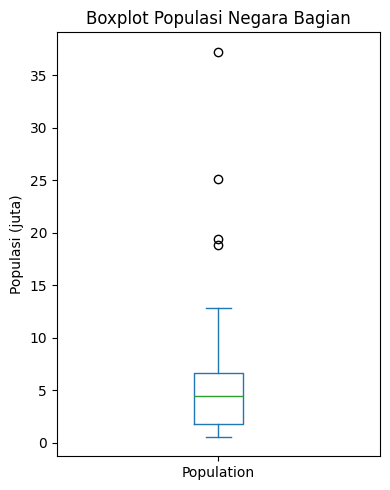

In [27]:
# Gambar 1-2: Boxplot populasi per negara bagian
ax = (state['Population'] / 1_000_000).plot.box(figsize=(4, 5))
ax.set_ylabel('Populasi (juta)')
plt.title('Boxplot Populasi Negara Bagian')
plt.tight_layout()
plt.show()

In [28]:
# Memeriksa aturan whisker 1,5 x IQR secara manual
q1, q3 = state['Population'].quantile([0.25, 0.75])
iqr = q3 - q1
batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr

print(f'Q1 = {q1:,.0f} | Q3 = {q3:,.0f} | IQR = {iqr:,.0f}')
print(f'Batas whisker: [{batas_bawah:,.0f} ; {batas_atas:,.0f}]')
print('\nNegara bagian di luar whisker (outlier pada boxplot):')
state.loc[state['Population'] > batas_atas, ['State', 'Population']].sort_values('Population', ascending=False)

Q1 = 1,833,004 | Q3 = 6,680,312 | IQR = 4,847,308
Batas whisker: [-5,437,958 ; 13,951,274]

Negara bagian di luar whisker (outlier pada boxplot):


,State,Population
4,California,37253956
42,Texas,25145561
31,New York,19378102
8,Florida,18801310


**Interpretasi:** dari boxplot terlihat median populasi negara bagian sekitar 5 juta, separuh negara bagian berada di antara sekitar 2 juta dan 7 juta, dan ada beberapa **outlier berpopulasi tinggi**.

### Tabel Frekuensi (Tabel 1-5)
`pandas.cut` memetakan nilai ke dalam segmen; dengan `value_counts` kita mendapatkan tabel frekuensi. Berikut populasi dibagi menjadi 10 bin berukuran sama.

In [29]:
binnedPopulation = pd.cut(state['Population'], 10)
binnedPopulation.value_counts().sort_index()

,count
Population,
"(526935.67, 4232659.0]",24
"(4232659.0, 7901692.0]",14
"(7901692.0, 11570725.0]",6
"(11570725.0, 15239758.0]",2
"(15239758.0, 18908791.0]",1
"(18908791.0, 22577824.0]",1
"(22577824.0, 26246857.0]",1
"(26246857.0, 29915890.0]",0
"(29915890.0, 33584923.0]",0


In [30]:
# Tabel 1-5 lengkap: nomor bin, rentang, jumlah, dan negara bagian di tiap bin
tabel_1_5 = (state.groupby(binnedPopulation, observed=False)['Abbreviation']
                  .agg(Count='count', States=lambda s: ','.join(s)))
tabel_1_5.index = [f'{iv.left:,.0f} – {iv.right:,.0f}' for iv in tabel_1_5.index]
tabel_1_5.index.name = 'BinRange'
tabel_1_5.insert(0, 'BinNumber', range(1, len(tabel_1_5) + 1))
tabel_1_5

,BinNumber,Count,States
BinRange,,,
"526,936 – 4,232,659",1,24,"AK,AR,CT,DE,HI,ID,IA,KS,ME,MS,MT,NE,NV,NH,NM,N..."
"4,232,659 – 7,901,692",2,14,"AL,AZ,CO,IN,KY,LA,MD,MA,MN,MO,SC,TN,WA,WI"
"7,901,692 – 11,570,725",3,6,"GA,MI,NJ,NC,OH,VA"
"11,570,725 – 15,239,758",4,2,"IL,PA"
"15,239,758 – 18,908,791",5,1,FL
"18,908,791 – 22,577,824",6,1,NY
"22,577,824 – 26,246,857",7,1,TX
"26,246,857 – 29,915,890",8,0,
"29,915,890 – 33,584,923",9,0,


**Interpretasi:** negara bagian paling sedikit penduduknya adalah **Wyoming** (563.626) dan yang terbanyak **California** (37.253.956), sehingga rentangnya 36.690.330. Dibagi 10 bin sama lebar, tiap bin selebar sekitar 3.669.033. Bin paling atas hanya berisi California dan **dua bin tepat di bawahnya kosong** (sebelum Texas). Ingat: bin kosong tetap penting karena menyampaikan informasi.

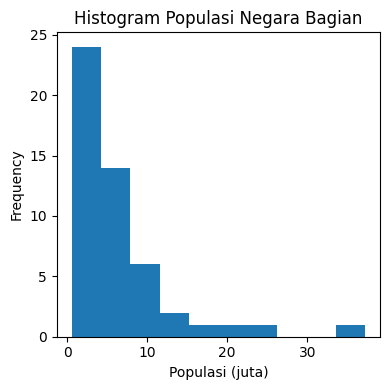

In [31]:
# Gambar 1-3: Histogram populasi per negara bagian
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Populasi (juta)')
plt.title('Histogram Populasi Negara Bagian')
plt.tight_layout()
plt.show()

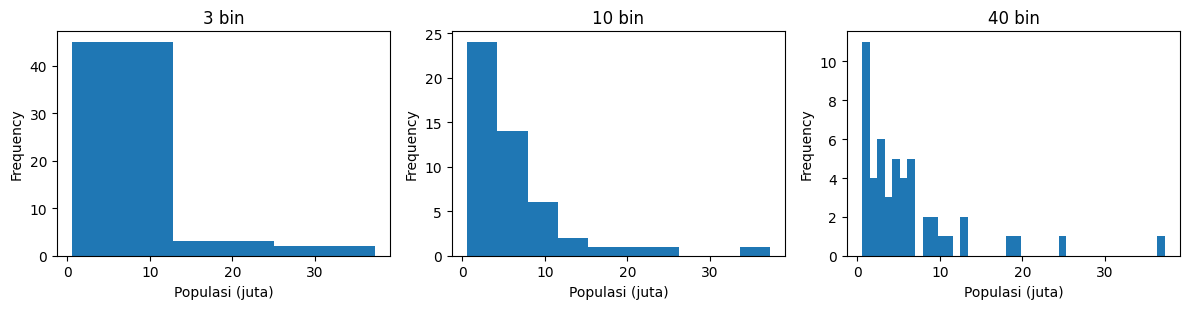

In [32]:
# Pengaruh jumlah bin: terlalu sedikit menyembunyikan struktur, terlalu banyak terlalu granular
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)
for ax, jumlah_bin in zip(axes, [3, 10, 40]):
    (state['Population'] / 1_000_000).plot.hist(bins=jumlah_bin, ax=ax)
    ax.set_title(f'{jumlah_bin} bin')
    ax.set_xlabel('Populasi (juta)')
plt.tight_layout()
plt.show()

In [33]:
# Skewness (momen ke-3) dan kurtosis (momen ke-4): pada praktiknya cukup dilihat dari plot
print('Skewness populasi :', round(state['Population'].skew(), 3), ' (positif = condong ke nilai besar)')
print('Kurtosis populasi :', round(state['Population'].kurt(), 3), ' (kelebihan kurtosis; > 0 = ekor lebih berat)')

Skewness populasi : 2.643  (positif = condong ke nilai besar)
Kurtosis populasi : 8.722  (kelebihan kurtosis; > 0 = ekor lebih berat)


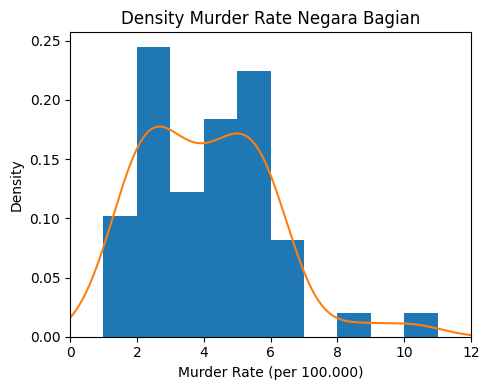

In [34]:
# Gambar 1-4: Density plot murder rate, ditumpuk di atas histogram (skala = proporsi)
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], bins=range(1, 12), figsize=(5, 4))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100.000)')
plt.title('Density Murder Rate Negara Bagian')
plt.tight_layout()
plt.show()

In [35]:
# Luas total di bawah kurva densitas = 1 (pendekatan numerik dengan integrasi trapezoid)
from scipy.stats import gaussian_kde
kde = gaussian_kde(state['Murder.Rate'])
xs = np.linspace(-5, 17, 2000)
print('Luas total di bawah kurva KDE :', round(np.trapezoid(kde(xs), xs), 4))
print('Proporsi murder rate antara 4 dan 6 menurut KDE :',
      round(np.trapezoid(kde(np.linspace(4, 6, 500)), np.linspace(4, 6, 500)), 4))

Luas total di bawah kurva KDE : 1.0
Proporsi murder rate antara 4 dan 6 menurut KDE : 0.3282


### Key Ideas
- **Histogram frekuensi** memplot hitungan frekuensi di sumbu-y dan nilai variabel di sumbu-x; memberi gambaran distribusi data sekilas.
- **Tabel frekuensi** adalah versi tabular dari hitungan frekuensi pada histogram.
- **Boxplot** (sisi kotak = persentil 75 dan 25) juga memberi gambaran cepat tentang distribusi; sering dipakai berdampingan untuk **membandingkan distribusi**.
- **Density plot** adalah versi histogram yang dihaluskan; membutuhkan fungsi untuk mengestimasi kurva dari data (banyak estimator yang mungkin).

---
## 6. Mengeksplorasi Data Biner dan Kategorikal

Untuk data kategorikal, **proporsi atau persentase sederhana** sudah menceritakan sebagian besar isi data.

### Istilah Kunci

| Istilah | Penjelasan |
|---|---|
| **Mode** | Kategori atau nilai yang paling sering muncul dalam dataset |
| **Expected value** (nilai harapan) | Bila kategori dapat dikaitkan dengan nilai numerik, ini adalah nilai rata-rata berdasarkan probabilitas kemunculan tiap kategori |
| **Bar chart** | Frekuensi atau proporsi tiap kategori digambarkan sebagai batang |
| **Pie chart** | Frekuensi atau proporsi tiap kategori digambarkan sebagai irisan lingkaran |

Meringkas variabel biner atau kategorikal dengan sedikit kategori cukup mudah: hitung proporsi nilai 1, atau proporsi kategori-kategori penting. Contoh: persentase keterlambatan penerbangan menurut penyebab di Bandara Dallas/Fort Worth (DFW) sejak 2010. Penyebabnya: kendali maskapai (*Carrier*), sistem kendali lalu lintas udara (*ATC*), cuaca (*Weather*), keamanan (*Security*), atau pesawat masuk yang terlambat (*Inbound*).

### Bar Chart vs Histogram
- **Bar chart**: sumbu-x berisi **kategori berbeda** dari variabel faktor; batang **terpisah** satu sama lain.
- **Histogram**: sumbu-x berisi **nilai numerik** dari satu variabel; batang biasanya **bersentuhan**, celah menunjukkan nilai yang tidak muncul.
- Histogram dan bar chart mirip, kecuali kategori pada bar chart **tidak berurutan**.
- **Pie chart** adalah alternatif bar chart, tetapi para statistisi dan ahli visualisasi data umumnya **menghindarinya** karena kurang informatif secara visual.

> **Data numerik sebagai data kategorikal.** Tabel frekuensi (binning) secara implisit mengubah data numerik menjadi *ordered factor*. Mengubah data numerik menjadi kategorikal adalah langkah penting dan umum karena **mengurangi kompleksitas (dan ukuran) data**, serta membantu menemukan hubungan antar fitur pada tahap awal analisis.

### Mode
**Mode** adalah nilai (atau nilai-nilai bila seri) yang paling sering muncul. Mode untuk penyebab keterlambatan di DFW adalah **"Inbound"**. Mode adalah statistik ringkasan sederhana untuk data kategorikal dan umumnya **tidak dipakai untuk data numerik**.

### Expected Value (Nilai Harapan)
Jenis khusus data kategorikal: kategori mewakili/dapat dipetakan ke nilai diskrit pada skala yang sama. Contoh: pemasar teknologi cloud menawarkan dua tingkat layanan, **\$300/bulan** dan **\$50/bulan**. Dari peserta webinar gratis, perusahaan memperkirakan 5% mendaftar layanan \$300, 15% mendaftar layanan \$50, dan 80% tidak mendaftar. Ini dapat diringkas dalam satu *expected value*, yaitu **weighted mean dengan bobot berupa probabilitas**:

1. Kalikan tiap hasil dengan probabilitas kemunculannya.
2. Jumlahkan hasilnya.

$$EV = (0{,}05)(300) + (0{,}15)(50) + (0{,}80)(0) = 22{,}5$$

Jadi nilai harapan seorang peserta webinar adalah **\$22,50 per bulan**. Konsep ini fundamental dalam valuasi bisnis dan penganggaran modal (mis. nilai harapan keuntungan lima tahun dari akuisisi baru).

### Probabilitas
Probabilitas muncul dalam prakiraan cuaca (peluang hujan) atau analisis olahraga (peluang menang). Olahraga dan permainan lebih sering dinyatakan sebagai **odds**, yang mudah dikonversi ke probabilitas (bila odds sebuah tim menang adalah 2 banding 1, maka probabilitasnya $2/(2+1) = 2/3$). Secara operasional, probabilitas suatu peristiwa adalah **proporsi seberapa sering peristiwa itu terjadi bila situasinya dapat diulang terus-menerus tanpa batas**.

In [36]:
# Tabel 1-6: persentase keterlambatan menurut penyebab di Bandara DFW
dfw = pd.read_csv(DFW_AIRLINE_CSV)
persen_dfw = 100 * dfw / dfw.values.sum()
persen_dfw.round(2)

,Carrier,ATC,Weather,Security,Inbound
0,23.0200,30.4000,4.0300,0.1200,42.4300


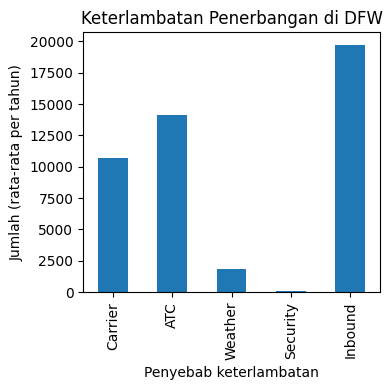

In [37]:
# Gambar 1-5: Bar chart keterlambatan di DFW per penyebab
# Dibagi 6 untuk mendapatkan rata-rata per tahun, mengikuti Gambar 1-5 versi R pada buku
ax = (dfw / 6).transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Penyebab keterlambatan')
ax.set_ylabel('Jumlah (rata-rata per tahun)')
plt.title('Keterlambatan Penerbangan di DFW')
plt.tight_layout()
plt.show()

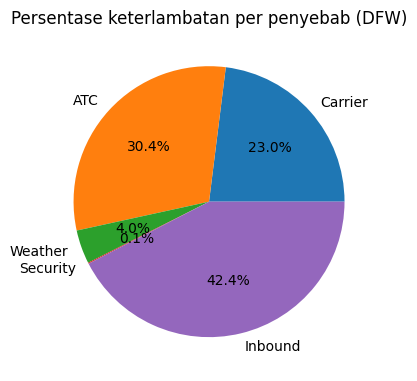

In [38]:
# Pie chart (alternatif, namun kurang disarankan oleh para ahli visualisasi)
ax = persen_dfw.iloc[0].plot.pie(figsize=(4, 4), autopct='%.1f%%', ylabel='')
plt.title('Persentase keterlambatan per penyebab (DFW)')
plt.tight_layout()
plt.show()

In [39]:
# Mode: kategori yang paling sering muncul
print('Mode penyebab keterlambatan di DFW:', dfw.iloc[0].idxmax())

Mode penyebab keterlambatan di DFW: Inbound


In [40]:
# Expected value layanan cloud: nilai x probabilitas, lalu dijumlahkan
nilai = np.array([300, 50, 0])           # $/bulan
probabilitas = np.array([0.05, 0.15, 0.80])

print('Probabilitas berjumlah 1? ->', probabilitas.sum() == 1)
print(f'Expected value = ${np.dot(nilai, probabilitas):.2f} per bulan')

# Konversi odds -> probabilitas: odds 2 banding 1  => P = 2 / (2 + 1)
odds = 2 / 1
print(f'Odds 2:1 -> probabilitas = {odds / (1 + odds):.4f}  (= 2/3)')

Probabilitas berjumlah 1? -> True
Expected value = $22.50 per bulan
Odds 2:1 -> probabilitas = 0.6667  (= 2/3)


### Key Ideas
- Data kategorikal umumnya diringkas dalam **proporsi** dan dapat divisualisasikan dalam **bar chart**.
- Kategori dapat mewakili hal yang berbeda (apel dan jeruk, laki-laki dan perempuan), **level variabel faktor** (rendah, sedang, tinggi), atau **data numerik yang di-bin**.
- **Expected value** adalah jumlah nilai × probabilitas kemunculannya, sering dipakai untuk meringkas level variabel faktor.

---
## 7. Korelasi

EDA pada banyak proyek pemodelan (data science maupun riset) melibatkan pemeriksaan **korelasi antar prediktor**, dan **antara prediktor dan variabel target**. Variabel $X$ dan $Y$ (keduanya data terukur) dikatakan:
- **berkorelasi positif** bila nilai $X$ tinggi berpasangan dengan nilai $Y$ tinggi, dan nilai $X$ rendah berpasangan dengan $Y$ rendah;
- **berkorelasi negatif** bila nilai $X$ tinggi berpasangan dengan $Y$ rendah, dan sebaliknya.

### Istilah Kunci

| Istilah | Penjelasan |
|---|---|
| **Correlation coefficient** | Metrik yang mengukur sejauh mana variabel numerik berasosiasi satu sama lain (rentang −1 sampai +1) |
| **Correlation matrix** | Tabel dengan variabel pada baris dan kolom; isi sel adalah korelasi antar variabel |
| **Scatterplot** | Plot dengan sumbu-x = nilai satu variabel dan sumbu-y = nilai variabel lain |

### Dari jumlah hasil kali ke koefisien korelasi
Perhatikan dua variabel yang berkorelasi sempurna: `v1 = {1, 2, 3}` dan `v2 = {4, 5, 6}`. Jumlah hasil kali vektornya $1\cdot4 + 2\cdot5 + 3\cdot6 = 32$. Bila salah satu diacak lalu dihitung ulang, jumlah hasil kalinya **tidak akan pernah lebih tinggi dari 32**. Namun nilai ini tidak bermakna kecuali dibandingkan dengan distribusi resampling (konsep ini terkait *permutation test*, dibahas di Bab 3).

Yang lebih berguna adalah varian terstandarisasi: **koefisien korelasi Pearson**, yang selalu berada pada skala yang sama. Caranya: kalikan deviasi dari mean variabel 1 dengan variabel 2, lalu bagi dengan hasil kali standar deviasinya:

$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{(n-1)\, s_x s_y}$$

Pembaginya memakai $n-1$ (lihat bahasan derajat kebebasan). Nilai $r$ selalu di antara **+1** (korelasi positif sempurna) dan **−1** (korelasi negatif sempurna); **0** berarti tidak ada korelasi.

**Peringatan:** variabel dapat berasosiasi secara **non-linear**, sehingga koefisien korelasi bisa jadi bukan metrik yang berguna. Contoh: hubungan tarif pajak dan penerimaan pajak. Saat tarif naik dari nol, penerimaan naik, tetapi ketika tarif mendekati 100%, penghindaran pajak meningkat dan penerimaan justru turun.

Seperti mean dan standar deviasi, koefisien korelasi **sensitif terhadap outlier**. Tersedia alternatif robust (mis. `covRob` di paket R `robust`, atau modul `sklearn.covariance` pada scikit-learn).

> **Estimasi korelasi lainnya.** *Spearman's rho* dan *Kendall's tau* adalah koefisien korelasi berbasis **peringkat (rank)** data. Karena memakai peringkat, estimasi ini robust terhadap outlier dan dapat menangani sebagian jenis non-linearitas. Namun untuk eksplorasi, data scientist umumnya cukup memakai korelasi Pearson dan alternatif robust-nya; peringkat lebih menarik untuk dataset kecil dan uji hipotesis tertentu.

In [41]:
# Intuisi: jumlah hasil kali v1.v2 paling besar saat kedua variabel 'searah'
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])

print('Jumlah hasil kali (urutan asli) :', np.dot(v1, v2))
print('\nSemua kemungkinan pengacakan v2:')
for p in permutations(v2):
    print('  ', tuple(int(i) for i in p), '->', np.dot(v1, p))
print('\nMaksimum =', max(np.dot(v1, p) for p in permutations(v2)), ' (tidak pernah melebihi 32)')

Jumlah hasil kali (urutan asli) : 32

Semua kemungkinan pengacakan v2:
   (4, 5, 6) -> 32
   (4, 6, 5) -> 31
   (5, 4, 6) -> 31
   (5, 6, 4) -> 29
   (6, 4, 5) -> 29
   (6, 5, 4) -> 28

Maksimum = 32  (tidak pernah melebihi 32)


In [42]:
# Memuat data return harian saham S&P 500 dan informasi sektor
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)
sp500_sym = pd.read_csv(SP500_SECTORS_CSV)

print('sp500_px  :', sp500_px.shape, '(hari x simbol saham)')
print('sp500_sym :', sp500_sym.shape)
sp500_sym.head()

sp500_px  : (5647, 517) (hari x simbol saham)
sp500_sym : (517, 4)


,sector,sector_label,sub_sector,symbol
0,information_technology,Technology,data_processing_&_outsourced_services,ADS
1,information_technology,Technology,systems_software,CA
2,information_technology,Technology,systems_software,MSFT
3,information_technology,Technology,systems_software,RHT
4,information_technology,Technology,it_consulting_&_services,CTSH


In [43]:
# Tabel 1-7: korelasi return harian saham telekomunikasi (Juli 2012 - Juni 2015)
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', ['T', 'CTL', 'FTR', 'VZ', 'LVLT']]
print('Jumlah hari perdagangan:', len(telecom))
telecom.corr().round(3)

Jumlah hari perdagangan: 754


,T,CTL,FTR,VZ,LVLT
T,1.0000,0.4750,0.3280,0.6780,0.2790
CTL,0.4750,1.0000,0.4200,0.4170,0.2870
FTR,0.3280,0.4200,1.0000,0.2870,0.2600
VZ,0.6780,0.4170,0.2870,1.0000,0.2420
LVLT,0.2790,0.2870,0.2600,0.2420,1.0000


In [44]:
# Verifikasi rumus Pearson secara manual untuk pasangan AT&T (T) dan Verizon (VZ)
a, b = telecom['T'], telecom['VZ']
n = len(a)
r_manual = ((a - a.mean()) * (b - b.mean())).sum() / ((n - 1) * a.std() * b.std())

print('r manual (rumus)  :', round(r_manual, 4))
print('r pandas (.corr)  :', round(a.corr(b), 4))

r manual (rumus)  : 0.6776
r pandas (.corr)  : 0.6776


**Interpretasi:** **Verizon (VZ)** dan **AT&T (T)** memiliki korelasi tertinggi (≈ 0,678). **Level 3 (LVLT)**, perusahaan infrastruktur, memiliki korelasi terendah dengan yang lain. Perhatikan diagonal bernilai 1 (korelasi saham dengan dirinya sendiri) dan redundansi informasi di atas dan di bawah diagonal.

ETF: ['XLI', 'QQQ', 'SPY', 'DIA', 'GLD', 'VXX', 'USO', 'IWM', 'XLE', 'XLY', 'XLU', 'XLB', 'XTL', 'XLV', 'XLP', 'XLF', 'XLK']


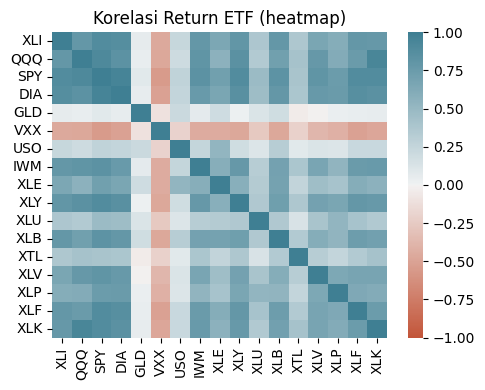

In [45]:
# Gambar 1-6 (versi heatmap): korelasi return harian ETF utama
etfs = sp500_px.loc[sp500_px.index > '2012-07-01',
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
print('ETF:', list(etfs.columns))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(etfs.corr(), vmin=-1, vmax=1,
            cmap=sns.diverging_palette(20, 220, as_cmap=True), ax=ax)
plt.title('Korelasi Return ETF (heatmap)')
plt.tight_layout()
plt.show()

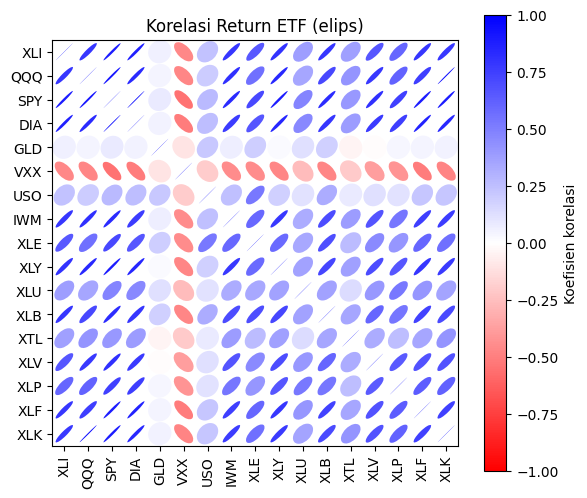

In [46]:
# Gambar 1-6 (versi elips, seperti paket 'corrplot' di R)
# Arah elips = tanda korelasi; elips makin tipis dan gelap = korelasi makin kuat.
def plot_corr_ellipses(data, figsize=None, **kwargs):
    # Sumber ide: https://stackoverflow.com/a/34558488
    M = np.array(data)
    if not M.ndim == 2:
        raise ValueError('data must be a 2D array')
    fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'aspect': 'equal'})
    ax.set_xlim(-0.5, M.shape[1] - 0.5)
    ax.set_ylim(-0.5, M.shape[0] - 0.5)
    ax.invert_yaxis()

    # posisi (x, y) pusat tiap elips
    xy = np.indices(M.shape)[::-1].reshape(2, -1).T

    # ukuran sumbu mayor/minor menyesuaikan kekuatan & arah korelasi
    w = np.ones_like(M).ravel() + 0.01
    h = 1 - np.abs(M).ravel() - 0.01
    a = 45 * np.sign(M).ravel()

    ec = EllipseCollection(widths=w, heights=h, angles=a, units='x', offsets=xy,
                           norm=Normalize(vmin=-1, vmax=1),
                           offset_transform=ax.transData, array=M.ravel(), **kwargs)
    ax.add_collection(ec)

    # bila data berupa DataFrame, pakai nama baris/kolom sebagai label sumbu
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(M.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(data.index)
    return ec, ax

m = plot_corr_ellipses(etfs.corr(), figsize=(6, 6), cmap='bwr_r')
cb = plt.colorbar(m[0], ax=m[1], orientation='vertical', shrink=0.8)
cb.set_label('Koefisien korelasi')
plt.title('Korelasi Return ETF (elips)')
plt.tight_layout()
plt.show()

**Interpretasi:** ETF **S&P 500 (SPY)** dan **Dow Jones (DIA)** berkorelasi tinggi. Demikian pula **QQQ** dan **XLK** (didominasi perusahaan teknologi) berkorelasi positif. ETF defensif seperti emas (**GLD**), minyak (**USO**), atau volatilitas pasar (**VXX**) cenderung berkorelasi **lemah atau negatif** dengan ETF lain. Pada plot elips, arah elips menunjukkan tanda korelasi (miring ke kanan-atas = positif, ke kiri-atas = negatif), sedangkan warna dan ketipisan elips menunjukkan kekuatan hubungan.

### Scatterplot
Cara standar memvisualisasikan hubungan antara dua variabel terukur adalah **scatterplot**: sumbu-x satu variabel, sumbu-y variabel lain, dan tiap titik adalah satu record.

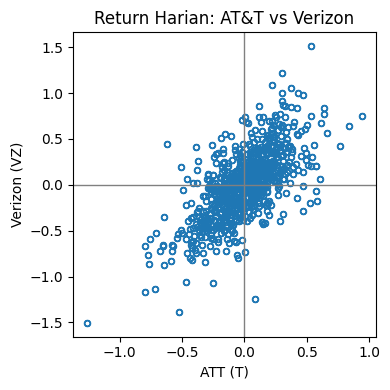

In [47]:
# Gambar 1-7: Scatterplot return harian AT&T (T) vs Verizon (VZ)
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)
plt.title('Return Harian: AT&T vs Verizon')
plt.tight_layout()
plt.show()

**Interpretasi:** return berhubungan **positif**. Pada sebagian besar hari, kedua saham naik atau turun bersamaan (kuadran kanan-atas dan kiri-bawah); hanya sedikit hari ketika satu saham turun signifikan sementara yang lain naik. Plot ini hanya menampilkan 754 titik, namun sudah sulit melihat detail di bagian tengah; di subbab 8 kita akan melihat cara mengatasinya (hexagonal binning dan density plot).

### Key Ideas
- **Koefisien korelasi** mengukur sejauh mana dua variabel berpasangan (mis. tinggi dan berat badan) saling berasosiasi.
- Bila nilai tinggi `v1` berpasangan dengan nilai tinggi `v2`, keduanya berasosiasi **positif**; bila tinggi berpasangan dengan rendah, **negatif**.
- Koefisien korelasi adalah metrik terstandarisasi, selalu berkisar dari **−1** (negatif sempurna) hingga **+1** (positif sempurna).
- Koefisien **nol** berarti tidak ada korelasi, tetapi ingat bahwa susunan data acak pun akan menghasilkan koefisien positif maupun negatif **hanya karena kebetulan**.

---
## 8. Mengeksplorasi Dua Variabel atau Lebih

Estimator familiar seperti mean dan variansi melihat variabel satu per satu (**analisis univariat**). Analisis korelasi membandingkan dua variabel (**analisis bivariat**). Pada subbab ini kita melihat estimasi dan plot tambahan, serta analisis lebih dari dua variabel (**analisis multivariat**).

### Istilah Kunci

| Istilah | Penjelasan |
|---|---|
| **Contingency table** | Tabel hitungan antara dua atau lebih variabel kategorikal |
| **Hexagonal binning** | Plot dua variabel numerik dengan record dikelompokkan ke dalam segi enam |
| **Contour plot** | Plot yang menunjukkan kepadatan dua variabel numerik seperti peta topografi |
| **Violin plot** | Mirip boxplot, tetapi menampilkan estimasi densitas |

Seperti analisis univariat, analisis bivariat/multivariat melibatkan **penghitungan statistik ringkasan** dan **tampilan visual**. Jenis analisis yang tepat bergantung pada sifat data: numerik vs kategorikal.

### Hexagonal Binning dan Kontur (Numerik vs Numerik)
Scatterplot cocok bila jumlah data relatif kecil. Untuk dataset dengan ratusan ribu hingga jutaan record, scatterplot akan **terlalu padat** (menjadi "awan hitam"), sehingga diperlukan cara lain. Sebagai ilustrasi dipakai dataset `kc_tax` berisi **nilai taksiran pajak properti hunian di King County, Washington**. Agar fokus pada bagian utama data, rumah yang sangat mahal serta hunian yang sangat kecil atau besar dibuang.

In [48]:
kc_tax = pd.read_csv(KC_TAX_CSV)
print('Data asli:', kc_tax.shape)

kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print('Setelah difilter:', kc_tax0.shape)
kc_tax0.head()

Data asli: (498249, 3)
Setelah difilter: (432693, 3)


,TaxAssessedValue,SqFtTotLiving,ZipCode
1,"206,000.0000",1870,"98,002.0000"
2,"303,000.0000",1530,"98,166.0000"
3,"361,000.0000",2000,"98,108.0000"
4,"459,000.0000",3150,"98,108.0000"
5,"223,000.0000",1570,"98,032.0000"


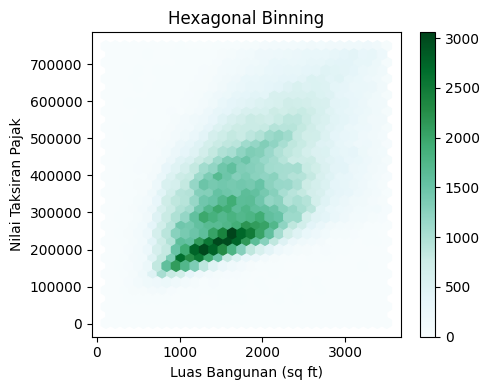

In [49]:
# Gambar 1-8: Hexagonal binning, nilai taksiran pajak vs luas bangunan (kaki persegi)
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Luas Bangunan (sq ft)')
ax.set_ylabel('Nilai Taksiran Pajak')
plt.title('Hexagonal Binning')
plt.tight_layout()
plt.show()

**Interpretasi:** daripada memplot titik (yang akan menjadi awan pekat), record dikelompokkan ke dalam **segi enam** dan warna menunjukkan **jumlah record** di tiap segi enam. Hubungan **positif** antara luas bangunan dan nilai taksiran terlihat jelas. Fitur menarik: ada **pita tambahan** di atas pita utama (paling gelap) di bagian bawah, yaitu rumah dengan luas sama tetapi nilai taksiran lebih tinggi.

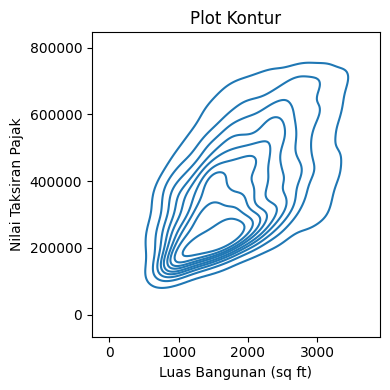

In [50]:
# Gambar 1-9: Plot kontur (KDE 2D). Memakai sampel 10.000 titik agar komputasi KDE cepat.
sampel = kc_tax0.sample(10_000, random_state=1)

fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=sampel, x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Luas Bangunan (sq ft)')
ax.set_ylabel('Nilai Taksiran Pajak')
plt.title('Plot Kontur')
plt.tight_layout()
plt.show()

**Interpretasi:** kontur bekerja seperti **peta topografi** untuk dua variabel; tiap pita kontur menunjukkan kepadatan titik tertentu yang meningkat saat mendekati "puncak". Plot ini bercerita sama dengan hexagonal binning: ada **puncak sekunder** di "utara" puncak utama. *Heat map*, hexagonal binning, dan plot kontur sama-sama memberi representasi visual **kepadatan dua dimensi**, sehingga merupakan analog natural dari histogram dan density plot.

### Dua Variabel Kategorikal
**Contingency table** (tabel kontingensi) meringkas dua variabel kategorikal sebagai tabel hitungan per kategori. Berikut tabel kontingensi antara **grade** pinjaman pribadi (A = tertinggi sampai G = terendah) dan **status** pinjaman (*Fully Paid*, *Current*, *Late*, *Charged Off*) dari data **Lending Club** (pinjaman peer-to-peer). Tabel dapat menampilkan hitungan saja, atau juga persentase baris, kolom, dan total. Pivot table di Excel mungkin alat paling umum untuk ini.

In [51]:
lc_loans = pd.read_csv(LC_LOANS_CSV)
lc_loans.head()

,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B


In [52]:
# Tabel 1-8 (bagian hitungan): pivot_table dengan margins=True menambah total baris/kolom
crosstab = lc_loans.pivot_table(index='grade', columns='status',
                                aggfunc=lambda x: len(x), margins=True)
crosstab

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


In [53]:
# Tabel 1-8 (bagian persentase baris)
df = crosstab.loc['A':'G', :].astype(float)                         # abaikan baris total; float agar bisa menampung proporsi
df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(df['All'], axis=0)  # bagi dgn total baris
df['All'] = df['All'] / sum(df['All'])                              # kolom 'All' = proporsi tiap grade
perc_crosstab = df
perc_crosstab.round(3)

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,0.0220,0.6900,0.2820,0.0060,0.1610
B,0.0400,0.7090,0.2350,0.0160,0.2940
C,0.0500,0.7360,0.1910,0.0230,0.2680
D,0.0670,0.7170,0.1840,0.0310,0.1650
E,0.0820,0.7080,0.1710,0.0390,0.0770
F,0.1180,0.6540,0.1800,0.0470,0.0290
G,0.1260,0.6140,0.1980,0.0610,0.0070


**Interpretasi:** pinjaman berkualitas tinggi (grade A) memiliki persentase **late/charged-off yang sangat rendah** (sekitar 2,2% *charged off*), sedangkan pinjaman grade rendah jauh lebih tinggi (grade G sekitar 12,6%). Semakin rendah grade, semakin besar risiko gagal bayar.

In [54]:
# Alternatif lebih ringkas dengan pd.crosstab (normalize='index' = persentase per baris)
pd.crosstab(lc_loans['grade'], lc_loans['status'], normalize='index').round(3)

status,Charged Off,Current,Fully Paid,Late
grade,,,,
A,0.0220,0.6900,0.2820,0.0060
B,0.0400,0.7090,0.2350,0.0160
C,0.0500,0.7360,0.1910,0.0230
D,0.0670,0.7170,0.1840,0.0310
E,0.0820,0.7080,0.1710,0.0390
F,0.1180,0.6540,0.1800,0.0470
G,0.1260,0.6140,0.1980,0.0610


### Data Kategorikal dan Numerik
**Boxplot** adalah cara sederhana untuk membandingkan secara visual distribusi variabel numerik yang dikelompokkan menurut variabel kategorikal. Contoh: membandingkan persentase keterlambatan penerbangan antar maskapai (khususnya keterlambatan yang berada dalam kendali maskapai).

In [55]:
airline_stats = pd.read_csv(AIRLINE_STATS_CSV)
airline_stats.head()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.1532,1.9718,0.7621,American
1,5.9599,3.7061,1.5859,American
2,7.1573,2.7062,2.0267,American
3,12.1000,11.0333,0.0000,American
4,7.3333,3.3656,1.7742,American


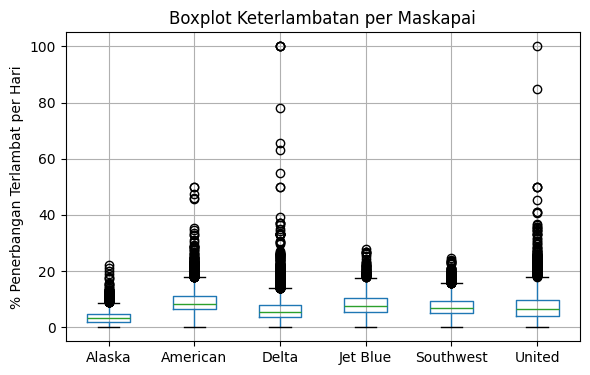

In [56]:
# Gambar 1-10: Boxplot persentase keterlambatan per maskapai
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay', figsize=(6, 4))
ax.set_xlabel('')
ax.set_ylabel('% Penerbangan Terlambat per Hari')
plt.suptitle('')
plt.title('Boxplot Keterlambatan per Maskapai')
plt.tight_layout()
plt.show()

**Interpretasi:** **Alaska** tampil dengan keterlambatan paling sedikit, sedangkan **American** paling banyak. Kuartil bawah American bahkan lebih tinggi daripada kuartil atas Alaska.

**Violin plot** (Hintze & Nelson, 1998) adalah penyempurnaan boxplot: memplot **estimasi densitas** dengan densitas di sumbu-y, dicerminkan dan dibalik lalu diisi sehingga menyerupai biola. Keunggulannya: dapat menunjukkan **nuansa distribusi yang tak terlihat di boxplot**. Sebaliknya, boxplot lebih jelas menampilkan **outlier**.

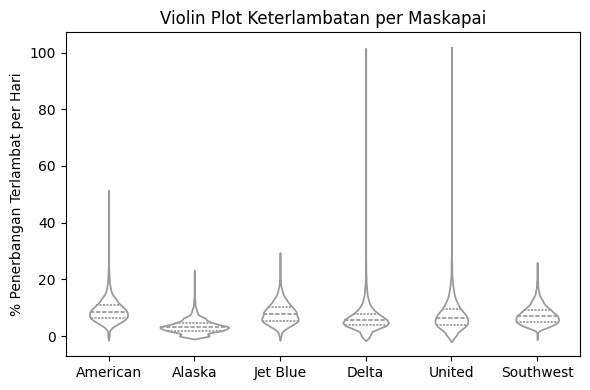

In [57]:
# Gambar 1-11: Violin plot persentase keterlambatan per maskapai
fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               inner='quartile', color='white', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('% Penerbangan Terlambat per Hari')
plt.title('Violin Plot Keterlambatan per Maskapai')
plt.tight_layout()
plt.show()

**Interpretasi:** violin plot memperlihatkan **konsentrasi distribusi di dekat nol** untuk Alaska dan, pada tingkat lebih kecil, Delta, fenomena yang **tidak tampak jelas pada boxplot**.

### Memvisualisasikan Banyak Variabel
Jenis grafik untuk membandingkan dua variabel (scatterplot, hexagonal binning, boxplot) dapat diperluas ke lebih banyak variabel lewat konsep **conditioning** (pengondisian). Pada Gambar 1-8 terlihat ada gerombolan rumah dengan nilai taksiran per kaki persegi lebih tinggi. Dengan mengondisikan pada **kode pos** (*zip code*), gambarnya menjadi jauh lebih jelas: nilai taksiran jauh lebih tinggi di sebagian kode pos (98105, 98126) dibanding yang lain (98108, 98188). Perbedaan inilah yang menimbulkan gerombolan pada Gambar 1-8.

Di R, hal ini dilakukan dengan **facet** pada `ggplot2` (`facet_wrap`, `facet_grid`). Di Python, `seaborn` menyediakan `FacetGrid` yang relatif sederhana dibanding membuatnya langsung dengan Matplotlib.

Jumlah record pada 4 kode pos: 19690


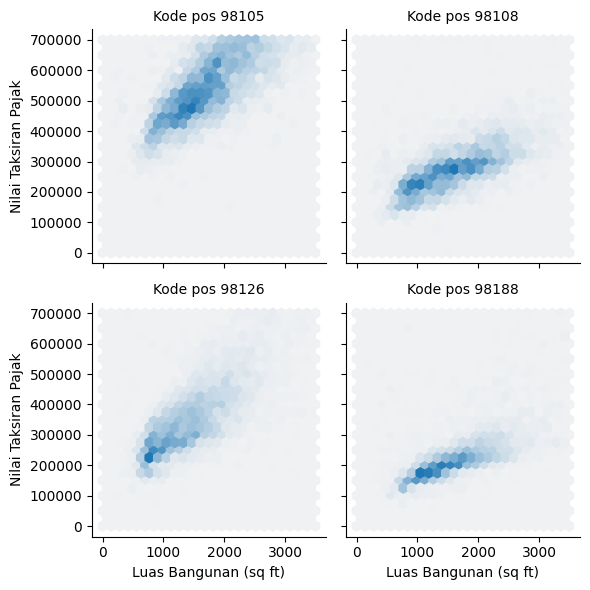

In [58]:
# Gambar 1-12: Nilai taksiran vs luas bangunan, dikondisikan pada kode pos (facet)
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]
print('Jumlah record pada 4 kode pos:', len(kc_tax_zip))

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue',
      extent=[0, 3500, 0, 700000])
g.set_axis_labels('Luas Bangunan (sq ft)', 'Nilai Taksiran Pajak')
g.set_titles('Kode pos {col_name:.0f}')
plt.show()

> **Sejarah singkat.** Konsep *conditioning variable* dipelopori oleh **Trellis graphics** (Rick Becker, Bill Cleveland, dkk. di Bell Labs) dan kini hadir di banyak sistem grafis modern: `lattice` dan `ggplot2` (R), `seaborn` dan `Bokeh` (Python), serta platform *business intelligence* seperti Tableau dan Spotfire. Meski platform visualisasi modern sudah jauh melampaui awal sederhana EDA, konsep dan alat yang dikembangkan setengah abad lalu (mis. boxplot sederhana) tetap menjadi fondasinya.

### Key Ideas
- **Hexagonal binning** dan **plot kontur** berguna untuk memeriksa dua variabel numerik sekaligus secara grafis, tanpa kewalahan oleh data berukuran sangat besar.
- **Tabel kontingensi** adalah alat standar untuk melihat hitungan dua variabel kategorikal.
- **Boxplot** dan **violin plot** memungkinkan kita memplot variabel numerik terhadap variabel kategorikal.

---
## 9. Ringkasan Bab

**Exploratory Data Analysis (EDA)**, yang dipelopori **John Tukey**, menjadi fondasi bagi bidang data science. Gagasan kuncinya: **langkah pertama dan terpenting dalam proyek berbasis data adalah melihat datanya**. Dengan meringkas dan memvisualisasikan data, kita memperoleh intuisi dan pemahaman berharga tentang proyek.

Bab ini membahas konsep mulai dari metrik sederhana (estimasi lokasi dan variabilitas) hingga tampilan visual yang kaya untuk menjelajahi hubungan antar banyak variabel. Ragam alat dan teknik dari komunitas *open source*, ditambah bahasa R dan Python yang ekspresif, menyediakan banyak cara untuk mengeksplorasi dan menganalisis data. **Analisis eksploratif harus menjadi landasan setiap proyek data science.**

### Rangkuman Konsep dan Fungsi Python

| Subbab | Konsep utama | Fungsi/Metode Python yang dipakai |
|---|---|---|
| **Elemen data terstruktur** | Numerik (kontinu, diskrit) & kategorikal (biner, ordinal) | `astype('category')`, `pd.Categorical(..., ordered=True)`, `OrdinalEncoder` |
| **Data rectangular** | Data frame, fitur, record, outcome, index | `pd.DataFrame`, `.dtypes`, `.set_index()` |
| **Estimasi lokasi** | Mean, trimmed mean, median, weighted mean/median, robust, outlier | `.mean()`, `scipy.stats.trim_mean`, `.median()`, `np.average(weights=)`, `wquantiles.median` |
| **Estimasi variabilitas** | Deviasi, variansi, std, mean abs. deviation, MAD, range, IQR, persentil | `.std()`, `.var()`, `.quantile()`, `robust.scale.mad`, `np.percentile` |
| **Distribusi data** | Persentil, boxplot, tabel frekuensi, histogram, density plot | `.plot.box()`, `pd.cut` + `.value_counts()`, `.plot.hist()`, `.plot.density()` |
| **Data biner & kategorikal** | Mode, expected value, probabilitas, bar chart, pie chart | `.idxmax()`, `np.dot`, `.plot.bar()`, `.plot.pie()` |
| **Korelasi** | Koefisien Pearson, matriks korelasi, scatterplot | `.corr()`, `sns.heatmap`, `.plot.scatter()` |
| **Dua variabel atau lebih** | Hexagonal binning, kontur, tabel kontingensi, violin plot, conditioning/facet | `.plot.hexbin()`, `sns.kdeplot`, `.pivot_table()` / `pd.crosstab`, `.boxplot(by=)`, `sns.violinplot`, `sns.FacetGrid` |

### Pelajaran Penting
1. **Mean sensitif terhadap outlier**; gunakan **median** atau **trimmed mean** bila ada nilai ekstrem.
2. **Standar deviasi sensitif terhadap outlier**; **MAD** dan **IQR** lebih robust.
3. **Tipe data menentukan analisis dan visualisasi** yang tepat.
4. Gunakan **histogram/density/boxplot** untuk melihat bentuk distribusi, bukan hanya angka ringkasan.
5. Untuk data besar, **scatterplot tidak memadai**; pakai **hexagonal binning** atau **kontur**.
6. **Korelasi bukan kausalitas** dan hanya menangkap hubungan **linear**; selalu lihat scatterplot.
7. **Conditioning** (facet) dapat mengungkap struktur tersembunyi yang tak terlihat pada plot gabungan.

---
**Referensi:** Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists* (2nd ed.). O'Reilly Media. Kode & data: <https://github.com/gedeck/practical-statistics-for-data-scientists>